# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [6]:
# TODO
print("data size: ", df.shape)
print("column names: ", df.columns)
print("data types: ", df.info())

data size:  (1338, 7)
column names:  Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
data types:  None


## A.2. Missing values & Duplicate data

In [10]:
# TODO
missing_values = df.isna().sum()
dup_data = df.duplicated()
if missing_values.sum() > 0: 
    print(missing_values[missing_values > 0])
else: 
    print("không có giá trị bị thiếu!")
print("duplicate data: ", dup_data.sum())

không có giá trị bị thiếu!
duplicate data:  1


## A.3. Invalid values

In [18]:
# TODO
print("age <= 0: ", (df['age'] <= 0).sum())
print("bmi <= 0: ", (df['bmi'] <= 0).sum())
print("charges <= 0: ", (df['charges'] <= 0).sum())
print("dữ liệu sạch: không có missing, không có giá trị không hợp lệ!")

age <= 0:  0
bmi <= 0:  0
charges <= 0:  0
dữ liệu sạch: không có missing, không có giá trị không hợp lệ!


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [22]:
# TODO
s = df['bmi']
conditions = [s < 25, (s >= 25) & (s <= 30), s > 30]
choices = ['normal', 'overweight', 'obese']
df['bmi_group'] = np.select(conditions, choices, default='unknown')
print(df)

      age     sex     bmi  children smoker     region      charges   bmi_group
0      19  female  27.900         0    yes  southwest  16884.92400  overweight
1      18    male  33.770         1     no  southeast   1725.55230       obese
2      28    male  33.000         3     no  southeast   4449.46200       obese
3      33    male  22.705         0     no  northwest  21984.47061      normal
4      32    male  28.880         0     no  northwest   3866.85520  overweight
...   ...     ...     ...       ...    ...        ...          ...         ...
1333   50    male  30.970         3     no  northwest  10600.54830       obese
1334   18  female  31.920         0     no  northeast   2205.98080       obese
1335   18  female  36.850         0     no  southeast   1629.83350       obese
1336   21  female  25.800         0     no  southwest   2007.94500  overweight
1337   61  female  29.070         0    yes  northwest  29141.36030  overweight

[1338 rows x 8 columns]


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [56]:
# TODO
df
for col in ['age', 'bmi', 'charges']: 
    mean, median, mode  = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: mean={mean:.2f} median={median:.2f} mode={mode:.2f}")



age: mean=39.21 median=39.00 mode=18.00
bmi: mean=30.66 median=30.40 mode=32.30
charges: mean=13270.42 median=9382.03 mode=1639.56


## Group 2 — Dispersion

In [37]:
# TODO
for col in ['age', 'bmi', 'charges']: 
    s = df[col]
    range = s.max() - s.min()
    std = s.std()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    cv = std/s.mean()
    print(f"---{col}-----")
    print(f"range={range:.2f} std={std:.2f} iqr = {iqr:.2f} cv = {cv:.2f}")

---age-----
range=46.00 std=14.05 iqr = 24.00 cv = 0.36
---bmi-----
range=37.17 std=6.10 iqr = 8.40 cv = 0.20
---charges-----
range=62648.55 std=12110.01 iqr = 11899.63 cv = 0.91


## Group 3 — Location and Shape

____age____
P25 = 27.0 P50 = 39.0 P75 = 51.0
____bmi____
P25 = 26.29625 P50 = 30.4 P75 = 34.69375
____charges____
P25 = 4740.28715 P50 = 9382.033 P75 = 16639.912515


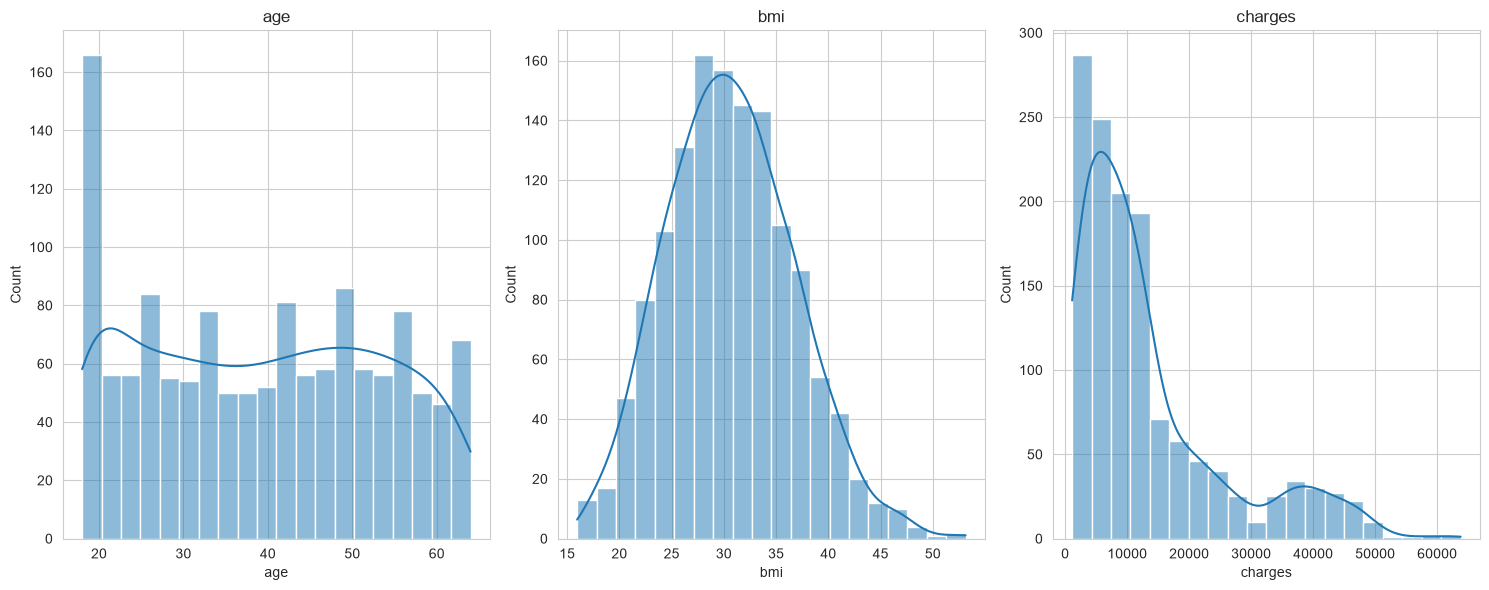

In [55]:
# TODO
for col in ['age', 'bmi', 'charges']: 
    s = df[col]
    skewness, kurtosis = stats.skew(s), stats.kurtosis(s)
    print(f"____{col}____")
    print(f"P25 = {s.quantile(0.25)} P50 = {s.quantile(0.5)} P75 = {s.quantile(0.75)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
sns.histplot(df['age'], bins=20,kde=True, ax=axes[0]);axes[0].set_title('age')
sns.histplot(df['bmi'], bins=20, kde=True, ax=axes[1]); axes[1].set_title('bmi')
sns.histplot(df['charges'], bins=20, kde=True, ax=axes[2]); axes[2].set_title('charges')
plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [75]:
# TODO
charges_by_smokers = df.groupby('smoker')['charges'].mean()
ratio_overall = charges_by_smokers['yes'] / charges_by_smokers['no']
print(f"Người hút thuốc trả phí cao gấp {ratio_overall:.2f} lần")
print(charges_by_smokers)
region_smoker = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
result = region_smoker['yes'] / region_smoker['no']
print(region_smoker)
print("bảng so sánh theo từng vùng: ")
print(result)
print("nhận xét: nhìn chung có sự phân bố khá đồng đều giữa các vùng mức chênh lệch không quá lớn và cao nhất ở vùng: southheast và thấp nhất ở vùng northheast.")

Người hút thuốc trả phí cao gấp 3.80 lần
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64
smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8556.463715  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494
bảng so sánh theo từng vùng: 
region
northeast    3.237514
northwest    3.528561
southeast    4.338155
southwest    4.023933
dtype: float64
nhận xét: nhìn chung có sự phân bố khá đồng đều giữa các vùng mức chênh lệch không quá lớn và cao nhất ở vùng: southheast và thấp nhất ở vùng northheast.


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [92]:
# TODO
corr_smoker = df.groupby('smoker')[['bmi', 'charges']].corr()
print(corr_smoker)
print("nhận xét: ")
print("nhóm không hút thuốc có hệ số tương quan r = 0.084037 là mức tương quan rất yếu")
print("nhóm hút thuốc có hệ số tương quan r = 0.806481 là mức tương quan mạnh")
print("kết luận: chỉ số bmi có sự tương quan với chi phí y tế ở nhóm hút thuốc mạnh hơn rất nhiều so với nhóm không hút thuốc")

                     bmi   charges
smoker                            
no     bmi      1.000000  0.084037
       charges  0.084037  1.000000
yes    bmi      1.000000  0.806481
       charges  0.806481  1.000000
nhận xét: 
nhóm không hút thuốc có hệ số tương quan r = 0.084037 là mức tương quan rất yếu
nhóm hút thuốc có hệ số tương quan r = 0.806481 là mức tương quan mạnh
kết luận: chỉ số bmi có sự tương quan với chi phí y tế ở nhóm hút thuốc mạnh hơn rất nhiều so với nhóm không hút thuốc


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [95]:
# TODO
Group_by_region = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print(Group_by_region)
print(f"vùng có chi phí bảo hiểm trung bình cao nhất là {Group_by_region.index[0]}")

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64
vùng có chi phí bảo hiểm trung bình cao nhất là southeast


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [98]:
# TODO
group_by_childrens = df.groupby('children')['charges'].mean()
print(group_by_childrens)
print("nhận xét: ")
print("số lượng con cái không làm tăng chi phí bảo hiểm 1 cách rõ rệt, cụ thể là: từ 0 đến 3 con mức chi phí tăng và từ 3 con trở đi thì mức chi phí có xu hướng giảm xuống")

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
nhận xét: 
số lượng con cái không làm tăng chi phí bảo hiểm 1 cách rõ rệt, cụ thể là: từ 0 đến 3 con mức chi phí tăng và từ 3 con trở đi thì mức chi phí có xu hướng giảm xuống


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [101]:
# TODO
corr_age_charges =df['age'].corr(df['charges'])
print(f"Hệ số tương quan giữa tuổi và chi phí: {corr_age_charges:.2f}")

Hệ số tương quan giữa tuổi và chi phí: 0.30


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Qua phân tích dữ liệu, yếu tố ảnh hưởng mạnh nhất đến chi phí bảo hiểm là việc hút thuốc (người hút thuốc trả chi phí cao hơn hẳn người không hút). Chỉ số BMI và tuổi tác cũng có tương quan thuận làm tăng chi phí, trong đó BMI tác động cực kỳ mạnh ở nhóm người có hút thuốc. Chi phí bảo hiểm giữa các vùng có sự chênh lệch nhẹ, với vùng southeast có mức trung bình cao nhất. Trong khi đó, số lượng con cái không có xu hướng làm tăng chi phí bảo hiểm một cách rõ rệt.